# CNN — simple upgrades for a small image-classification dataset

This notebook is a cleaned-up version of the original CNN search.  
The goal is not to make the pipeline complex, but to improve validation performance by fixing avoidable issues:

1. consistent label mapping between train and validation;
2. lighter/faster evaluation;
3. class-weighted loss for small/imbalanced datasets;
4. AdamW + scheduler + early stopping;
5. conservative augmentations;
6. optional transfer learning with `ResNet18`, which is usually the strongest simple upgrade for small image datasets.

In [1]:
import os
import random
import copy
import time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from torchvision import models

/home/rami/miniconda3/envs/skin-env/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
# -------------------------
# Reproducibility
# -------------------------
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # More deterministic, slightly slower. Useful when comparing hyperparameters.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# -------------------------
# Paths
# -------------------------
train_dir = "data/Split_smol/train"
val_dir = "data/Split_smol/val"

assert Path(train_dir).exists(), f"Train path not found: {train_dir}"
assert Path(val_dir).exists(), f"Validation path not found: {val_dir}"

In [4]:
# -------------------------
# Dataset with one shared class_to_idx
# -------------------------
class FolderImageDataset(Dataset):
    """ImageFolder-like dataset with Albumentations support and explicit class_to_idx.

    Expected structure:
        root/class_a/img1.jpg
        root/class_b/img2.jpg

    Important:
        Fit class_to_idx on train and reuse it for validation/test.
        This avoids the label-index mismatch risk that appeared in the MLP workflow.
    """

    IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    def __init__(self, root_dir, transform=None, class_to_idx=None):
        self.root_dir = Path(root_dir)
        self.transform = transform

        if class_to_idx is None:
            classes = sorted([p.name for p in self.root_dir.iterdir() if p.is_dir()])
            self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
        else:
            self.class_to_idx = dict(class_to_idx)

        self.idx_to_class = {idx: cls_name for cls_name, idx in self.class_to_idx.items()}
        self.classes = [self.idx_to_class[i] for i in range(len(self.idx_to_class))]

        self.samples = []
        for cls_name, cls_idx in self.class_to_idx.items():
            cls_dir = self.root_dir / cls_name
            if not cls_dir.exists():
                continue

            for ext in self.IMG_EXTENSIONS:
                self.samples.extend([(p, cls_idx) for p in cls_dir.rglob(f"*{ext}")])
                self.samples.extend([(p, cls_idx) for p in cls_dir.rglob(f"*{ext.upper()}")])

        self.samples = sorted(self.samples, key=lambda x: str(x[0]))

        if len(self.samples) == 0:
            raise ValueError(f"No images found in {self.root_dir}")

        self.labels = [label for _, label in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = np.array(Image.open(img_path).convert("RGB"))

        if self.transform is not None:
            image = self.transform(image=image)["image"]

        return image, label

In [5]:
# -------------------------
# Transforms
# -------------------------
# ImageNet normalization is required for pretrained torchvision models.
# It also works reasonably well for a scratch CNN.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def build_transforms(input_size=128, augment=True):
    if augment:
        return A.Compose([
            A.Resize(input_size, input_size),

            # Safe for many skin/texture datasets. 
            # For object datasets where upside-down images are unrealistic, remove VerticalFlip.
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.25),

            # Conservative geometric noise. Avoid extreme rotations on small datasets.
            A.ShiftScaleRotate(
                shift_limit=0.05,
                scale_limit=0.10,
                rotate_limit=15,
                p=0.5
            ),

            # Conservative photometric augmentation.
            # Avoid aggressive color shifts if color is diagnostically important.
            A.RandomBrightnessContrast(
                brightness_limit=0.15,
                contrast_limit=0.15,
                p=0.5
            ),

            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2()
        ])

    return A.Compose([
        A.Resize(input_size, input_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

In [6]:
# -------------------------
# Inspect class balance
# -------------------------
tmp_train = FolderImageDataset(train_dir, transform=None)
tmp_val = FolderImageDataset(val_dir, transform=None, class_to_idx=tmp_train.class_to_idx)

num_classes = len(tmp_train.classes)
classes = tmp_train.classes

train_counts = np.bincount(tmp_train.labels, minlength=num_classes)
val_counts = np.bincount(tmp_val.labels, minlength=num_classes)

balance_df = pd.DataFrame({
    "class": classes,
    "train_count": train_counts,
    "val_count": val_counts,
    "train_pct": train_counts / max(1, train_counts.sum()),
    "val_pct": val_counts / max(1, val_counts.sum()),
})

balance_df

,class,train_count,val_count,train_pct,val_pct
0,Actinic keratosis,80,20,0.117820,0.121212
1,Atopic Dermatitis,69,11,0.101620,0.066667
2,Benign keratosis,80,20,0.117820,0.121212
3,Dermatofibroma,80,20,0.117820,0.121212
4,Melanocytic nevus,80,20,0.117820,0.121212
5,Melanoma,80,20,0.117820,0.121212
6,Squamous cell carcinoma,80,20,0.117820,0.121212
7,Tinea Ringworm Candidiasis,50,14,0.073638,0.084848
8,Vascular lesion,80,20,0.117820,0.121212


In [7]:
# -------------------------
# Class weights
# -------------------------
def make_class_weights(labels, num_classes, device):
    counts = np.bincount(labels, minlength=num_classes).astype(np.float32)

    # Inverse-frequency weighting:
    # weight_c = N / (K * n_c)
    # where N = total samples, K = number of classes.
    counts_safe = np.maximum(counts, 1.0)
    weights = counts_safe.sum() / (num_classes * counts_safe)

    return torch.tensor(weights, dtype=torch.float32, device=device)


class_weights = make_class_weights(tmp_train.labels, num_classes, device)
class_weights

tensor([0.9431, 1.0934, 0.9431, 0.9431, 0.9431, 0.9431, 0.9431, 1.5089, 0.9431],
       device='cuda:0')

In [8]:
# -------------------------
# Model A: small scratch CNN
# -------------------------
class SmallCNN(nn.Module):
    """A compact CNN with BatchNorm and AdaptiveAvgPool.

    AdaptiveAvgPool avoids hardcoding the flattened size and makes the model compatible
    with 64, 128, or 224 px inputs.
    """

    def __init__(self, num_classes, dropout=0.30):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [9]:
# -------------------------
# Model B: transfer learning with ResNet18
# -------------------------
def build_resnet18(num_classes, dropout=0.30, pretrained=True, freeze_backbone=False):
    """Recommended simple upgrade for small datasets.

    Notes:
    - pretrained=True may download ImageNet weights the first time.
    - freeze_backbone=True trains only the final layer; useful as a first fast pass.
    - freeze_backbone=False fine-tunes the full network; usually better after the head is stable.
    """

    if pretrained:
        weights = models.ResNet18_Weights.DEFAULT
    else:
        weights = None

    model = models.resnet18(weights=weights)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    return model

In [10]:
# -------------------------
# Evaluation
# -------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device, use_tta=False):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        # Simple test-time augmentation: average original + horizontal flip.
        # Use only for final evaluation or if the validation metric is noisy.
        if use_tta:
            logits_flip = model(torch.flip(images, dims=[3]))
            logits = 0.5 * (logits + logits_flip)

        loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (preds == labels).sum().item()
        total_examples += batch_size

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / max(1, total_examples)
    accuracy = 100.0 * total_correct / max(1, total_examples)

    return avg_loss, accuracy, np.array(all_labels), np.array(all_preds)


def print_report(y_true, y_pred, classes):
    labels = list(range(len(classes)))

    print(classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=classes,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title("Validation confusion matrix")
    plt.tight_layout()
    plt.show()

In [11]:
# -------------------------
# Training loop
# -------------------------
def build_dataloaders(input_size=128, batch_size=32, num_workers=2):
    train_transform = build_transforms(input_size=input_size, augment=True)
    val_transform = build_transforms(input_size=input_size, augment=False)

    train_dataset = FolderImageDataset(train_dir, transform=train_transform)
    val_dataset = FolderImageDataset(
        val_dir,
        transform=val_transform,
        class_to_idx=train_dataset.class_to_idx
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    return train_dataset, val_dataset, train_loader, val_loader


def train_one_config(config):
    set_seed(config.get("seed", 42))

    train_dataset, val_dataset, train_loader, val_loader = build_dataloaders(
        input_size=config["input_size"],
        batch_size=config["batch_size"],
        num_workers=config.get("num_workers", 2)
    )

    num_classes = len(train_dataset.classes)
    classes = train_dataset.classes

    if config["model_name"] == "small_cnn":
        model = SmallCNN(
            num_classes=num_classes,
            dropout=config["dropout"]
        )
    elif config["model_name"] == "resnet18":
        model = build_resnet18(
            num_classes=num_classes,
            dropout=config["dropout"],
            pretrained=config.get("pretrained", True),
            freeze_backbone=config.get("freeze_backbone", False)
        )
    else:
        raise ValueError(f"Unknown model_name: {config['model_name']}")

    model = model.to(device)

    class_weights = make_class_weights(train_dataset.labels, num_classes, device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights if config.get("use_class_weights", True) else None,
        label_smoothing=config.get("label_smoothing", 0.0)
    )

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_state = None
    best = {
        "val_acc": -np.inf,
        "val_loss": np.inf,
        "train_acc": None,
        "train_loss": None,
        "epoch": -1
    }

    history = []
    bad_epochs = 0
    start_time = time.time()

    for epoch in range(1, config["epochs"] + 1):
        model.train()

        running_loss = 0.0
        running_correct = 0
        running_examples = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()

            if config.get("grad_clip_norm") is not None:
                nn.utils.clip_grad_norm_(model.parameters(), config["grad_clip_norm"])

            optimizer.step()

            preds = logits.argmax(dim=1)
            batch_size = labels.size(0)

            running_loss += loss.item() * batch_size
            running_correct += (preds == labels).sum().item()
            running_examples += batch_size

        train_loss = running_loss / max(1, running_examples)
        train_acc = 100.0 * running_correct / max(1, running_examples)

        val_loss, val_acc, y_true, y_pred = evaluate(
            model,
            val_loader,
            criterion,
            device,
            use_tta=False
        )

        scheduler.step(val_loss)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"]
        }
        history.append(row)

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}% | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        # Main score is validation accuracy. If tied, prefer lower validation loss.
        improved = (
            (val_acc > best["val_acc"]) or
            (np.isclose(val_acc, best["val_acc"]) and val_loss < best["val_loss"])
        )

        if improved:
            best.update({
                "val_acc": val_acc,
                "val_loss": val_loss,
                "train_acc": train_acc,
                "train_loss": train_loss,
                "epoch": epoch
            })
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= config["patience"]:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best['epoch']}")
            break

    elapsed_min = (time.time() - start_time) / 60

    if best_state is not None:
        model.load_state_dict(best_state)

    # Optional final TTA evaluation on the selected best model.
    final_val_loss, final_val_acc, y_true, y_pred = evaluate(
        model,
        val_loader,
        criterion,
        device,
        use_tta=config.get("use_tta_final", False)
    )

    result = {
        **config,
        **{f"best_{k}": v for k, v in best.items()},
        "final_val_loss": final_val_loss,
        "final_val_acc": final_val_acc,
        "elapsed_min": elapsed_min,
        "num_train": len(train_dataset),
        "num_val": len(val_dataset),
        "num_classes": num_classes,
    }

    return model, pd.DataFrame(history), result, (y_true, y_pred, classes)

In [12]:
# -------------------------
# Recommended first run
# -------------------------
# Start with this. It is usually the best simple upgrade for a small dataset.
config = {
    "model_name": "resnet18",
    "pretrained": True,
    "freeze_backbone": False,

    # For CPU, use 128. For GPU and better texture detail, try 224.
    "input_size": 128,

    # Avoid very large batch sizes on small datasets.
    "batch_size": 32,

    "lr": 3e-4,
    "weight_decay": 1e-4,
    "dropout": 0.30,
    "label_smoothing": 0.05,
    "use_class_weights": True,

    "epochs": 40,
    "patience": 8,
    "grad_clip_norm": 5.0,
    "use_tta_final": True,

    "seed": 42,
    "num_workers": 2
}

best_model, history, result, eval_payload = train_one_config(config)
result

/home/rami/miniconda3/envs/skin-env/lib/python3.12/site-packages/albumentations/core/validation.py:111: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/rami/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 63.4MB/s]


Epoch 001 | train_loss=1.3854 train_acc=55.38% | val_loss=1.0492 val_acc=72.12% | lr=3.00e-04
Epoch 002 | train_loss=0.8447 train_acc=77.76% | val_loss=1.0713 val_acc=72.12% | lr=3.00e-04
Epoch 003 | train_loss=0.7285 train_acc=82.03% | val_loss=0.9434 val_acc=75.76% | lr=3.00e-04
Epoch 004 | train_loss=0.7077 train_acc=83.51% | val_loss=1.2492 val_acc=72.73% | lr=3.00e-04
Epoch 005 | train_loss=0.6303 train_acc=86.75% | val_loss=0.9770 val_acc=75.76% | lr=3.00e-04
Epoch 006 | train_loss=0.5865 train_acc=89.25% | val_loss=1.0875 val_acc=70.91% | lr=3.00e-04
Epoch 007 | train_loss=0.5183 train_acc=92.34% | val_loss=0.9147 val_acc=75.15% | lr=3.00e-04
Epoch 008 | train_loss=0.5164 train_acc=92.05% | val_loss=0.9837 val_acc=76.97% | lr=3.00e-04
Epoch 009 | train_loss=0.5174 train_acc=92.19% | val_loss=1.0328 val_acc=75.76% | lr=3.00e-04
Epoch 010 | train_loss=0.4800 train_acc=93.67% | val_loss=1.0862 val_acc=74.55% | lr=3.00e-04
Epoch 011 | train_loss=0.4654 train_acc=93.67% | val_loss=1.

{'model_name': 'resnet18',
 'pretrained': True,
 'freeze_backbone': False,
 'input_size': 128,
 'batch_size': 32,
 'lr': 0.0003,
 'weight_decay': 0.0001,
 'dropout': 0.3,
 'label_smoothing': 0.05,
 'use_class_weights': True,
 'epochs': 40,
 'patience': 8,
 'grad_clip_norm': 5.0,
 'use_tta_final': True,
 'seed': 42,
 'num_workers': 2,
 'best_val_acc': 80.0,
 'best_val_loss': 0.9534483069723303,
 'best_train_acc': 98.23269513991164,
 'best_train_loss': 0.35769512981659185,
 'best_epoch': 17,
 'final_val_loss': 0.8641335967815283,
 'final_val_acc': 80.60606060606061,
 'elapsed_min': 0.6648231943448385,
 'num_train': 679,
 'num_val': 165,
 'num_classes': 9}

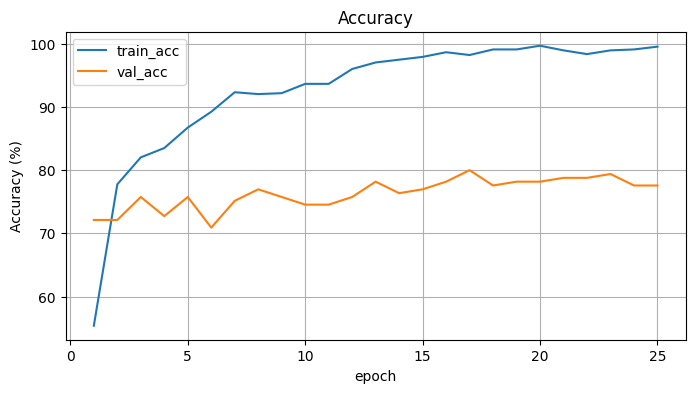

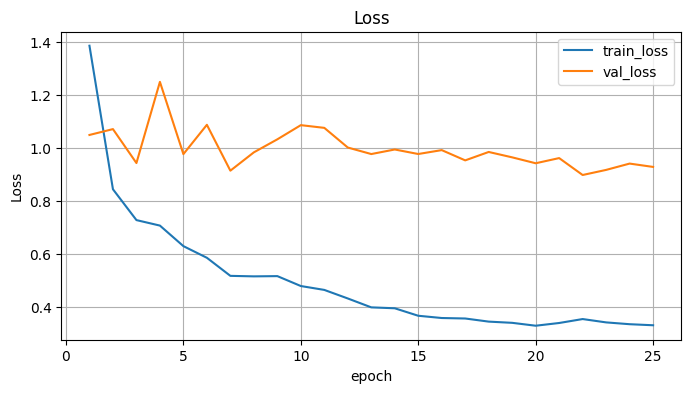

In [13]:
# Validation curves
history.plot(x="epoch", y=["train_acc", "val_acc"], figsize=(8, 4), grid=True)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy")
plt.show()

history.plot(x="epoch", y=["train_loss", "val_loss"], figsize=(8, 4), grid=True)
plt.ylabel("Loss")
plt.title("Loss")
plt.show()

                            precision    recall  f1-score   support

         Actinic keratosis       0.67      0.70      0.68        20
         Atopic Dermatitis       1.00      0.73      0.84        11
          Benign keratosis       0.91      1.00      0.95        20
            Dermatofibroma       0.89      0.85      0.87        20
         Melanocytic nevus       0.71      0.75      0.73        20
                  Melanoma       0.65      0.55      0.59        20
   Squamous cell carcinoma       0.61      0.70      0.65        20
Tinea Ringworm Candidiasis       1.00      1.00      1.00        14
           Vascular lesion       1.00      1.00      1.00        20

                  accuracy                           0.81       165
                 macro avg       0.83      0.81      0.81       165
              weighted avg       0.81      0.81      0.81       165



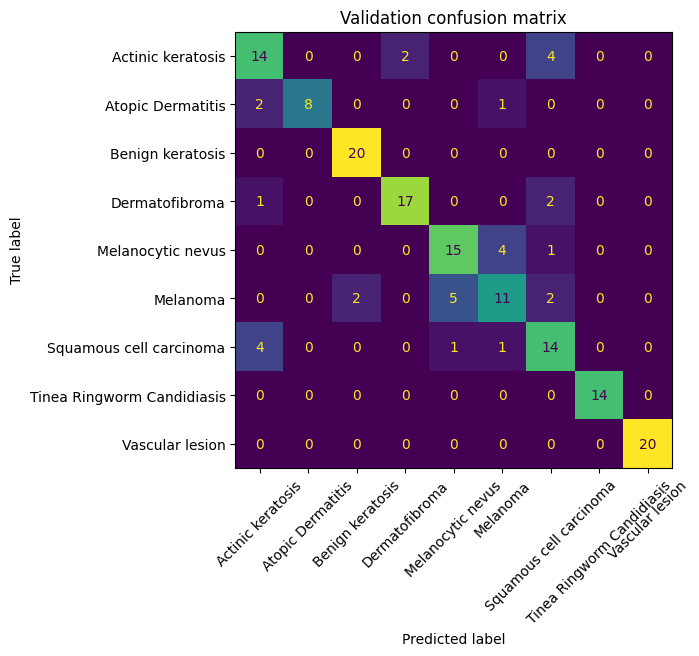

In [14]:
# Final validation report
y_true, y_pred, classes = eval_payload
print_report(y_true, y_pred, classes)

In [15]:
# Save selected model
torch.save({
    "model_state_dict": best_model.state_dict(),
    "config": config,
    "classes": classes
}, "best_resnet18_cnn.pt")

print("Saved: best_resnet18_cnn.pt")

Saved: best_resnet18_cnn.pt


In [16]:
# -------------------------
# Small random/manual search
# -------------------------
# Keep this small. The original notebook sampled ~5% of a 3456-combination grid,
# which still led to ~100+ model runs and many hours of CPU training.
# These configs are more focused and usually more informative.

candidate_configs = [
    {
        **config,
        "input_size": 128,
        "batch_size": 32,
        "lr": 3e-4,
        "dropout": 0.30,
        "weight_decay": 1e-4,
        "label_smoothing": 0.05,
        "seed": 42,
    },
    {
        **config,
        "input_size": 128,
        "batch_size": 16,
        "lr": 1e-4,
        "dropout": 0.40,
        "weight_decay": 1e-4,
        "label_smoothing": 0.05,
        "seed": 42,
    },
    {
        **config,
        "input_size": 224,
        "batch_size": 16,
        "lr": 1e-4,
        "dropout": 0.30,
        "weight_decay": 1e-4,
        "label_smoothing": 0.05,
        "seed": 42,
    },
    {
        **config,
        "model_name": "small_cnn",
        "pretrained": False,
        "freeze_backbone": False,
        "input_size": 128,
        "batch_size": 32,
        "lr": 1e-3,
        "dropout": 0.30,
        "weight_decay": 1e-4,
        "label_smoothing": 0.05,
        "seed": 42,
    },
]

search_results = []

for i, cfg in enumerate(candidate_configs, start=1):
    print(f"\n===== RUN {i}/{len(candidate_configs)}: {cfg['model_name']} =====")
    model_i, history_i, result_i, eval_payload_i = train_one_config(cfg)
    search_results.append(result_i)

results_df = pd.DataFrame(search_results).sort_values(
    ["final_val_acc", "best_val_acc"],
    ascending=False
)

results_df


===== RUN 1/4: resnet18 =====


/home/rami/miniconda3/envs/skin-env/lib/python3.12/site-packages/albumentations/core/validation.py:111: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Epoch 001 | train_loss=1.3795 train_acc=55.08% | val_loss=1.1978 val_acc=65.45% | lr=3.00e-04
Epoch 002 | train_loss=0.8524 train_acc=78.06% | val_loss=1.0519 val_acc=73.94% | lr=3.00e-04
Epoch 003 | train_loss=0.7358 train_acc=82.77% | val_loss=0.9771 val_acc=75.15% | lr=3.00e-04
Epoch 004 | train_loss=0.6839 train_acc=85.13% | val_loss=1.1815 val_acc=69.09% | lr=3.00e-04
Epoch 005 | train_loss=0.6315 train_acc=88.07% | val_loss=1.0189 val_acc=71.52% | lr=3.00e-04
Epoch 006 | train_loss=0.5918 train_acc=89.10% | val_loss=1.1027 val_acc=75.76% | lr=3.00e-04
Epoch 007 | train_loss=0.5120 train_acc=92.05% | val_loss=1.0396 val_acc=77.58% | lr=1.50e-04
Epoch 008 | train_loss=0.5045 train_acc=92.49% | val_loss=0.9205 val_acc=77.58% | lr=1.50e-04
Epoch 009 | train_loss=0.4463 train_acc=94.26% | val_loss=0.8768 val_acc=78.18% | lr=1.50e-04
Epoch 010 | train_loss=0.4133 train_acc=95.29% | val_loss=0.8553 val_acc=78.79% | lr=1.50e-04
Epoch 011 | train_loss=0.3942 train_acc=97.35% | val_loss=0.

,model_name,pretrained,freeze_backbone,input_size,batch_size,lr,weight_decay,dropout,label_smoothing,use_class_weights,...,best_val_loss,best_train_acc,best_train_loss,best_epoch,final_val_loss,final_val_acc,elapsed_min,num_train,num_val,num_classes
2,resnet18,True,False,224,16,0.0001,0.0001,0.3,0.05,True,...,0.693594,89.543446,0.572600,4,0.688539,86.666667,0.343829,679,165,9
0,resnet18,True,False,128,32,0.0003,0.0001,0.3,0.05,True,...,0.880209,98.674521,0.358214,15,0.829844,83.030303,0.601917,679,165,9
1,resnet18,True,False,128,16,0.0001,0.0001,0.4,0.05,True,...,0.824956,96.318115,0.429238,14,0.767403,82.424242,0.580230,679,165,9
3,small_cnn,False,False,128,32,0.0010,0.0001,0.3,0.05,True,...,1.081667,72.901325,0.983509,40,1.078381,68.484848,1.020548,679,165,9
